# **Dataset Preprocessing**

In [137]:
import pandas as pd
import numpy as np

In [86]:
df = pd.read_csv("../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv")
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [87]:
df.drop(columns=['FCVC'], inplace=True) # Due to unknown values 1,2,3 instead of 'Sometimes', 'Never', 'Always'

In [88]:
df.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

In [89]:
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [90]:
print("Numeric summary:")
display(df.describe(include=[np.number]).transpose())
print("\nAll columns summary:")
display(df.describe(include='all').transpose())

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00



All columns summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2111,2,Male,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2111.0,NaN,NaN,NaN,24.3126,6.345968,14.0,19.947192,22.77789,26.0,61.0
Height,2111.0,NaN,NaN,NaN,1.701677,0.093305,1.45,1.63,1.700499,1.768464,1.98
Weight,2111.0,NaN,NaN,NaN,86.586058,26.191172,39.0,65.473343,83.0,107.430682,173.0
family_history_with_overweight,2111,2,yes,1726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,2111,2,yes,1866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NCP,2111.0,NaN,NaN,NaN,2.685628,0.778039,1.0,2.658738,3.0,3.0,4.0
CAEC,2111,4,Sometimes,1765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMOKE,2111,2,no,2067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CH2O,2111.0,NaN,NaN,NaN,2.008011,0.612953,1.0,1.584812,2.0,2.47742,3.0


In [138]:
skewness = df.skew(numeric_only=True)
print(skewness)

Gender                           -0.023704
Age                               1.529100
Height                           -0.012855
Weight                            0.255410
family_history_with_overweight   -1.646216
FAVC                             -2.399125
NCP                              -1.107097
CAEC                             -1.907526
SMOKE                             6.712867
CH2O                             -0.104912
SCC                               4.366270
FAF                               0.498490
TUE                               0.618502
CALC                              0.236481
MTRANS                           -1.280169
NObeyesdad                        0.006754
dtype: float64


In [91]:
df['NObeyesdad'].value_counts()  # Checking the distribution of target variable

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [92]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
Numeric columns: ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF', 'TUE']


In [93]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC','CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.000000,1.620000,64.000000,1,0,3.0,2,0,2.000000,0,0.000000,1.000000,3,3,1
1,0,21.000000,1.520000,56.000000,1,0,3.0,2,1,3.000000,1,3.000000,0.000000,2,3,1
2,1,23.000000,1.800000,77.000000,1,0,3.0,2,0,2.000000,0,2.000000,1.000000,1,3,1
3,1,27.000000,1.800000,87.000000,0,0,3.0,2,0,2.000000,0,2.000000,0.000000,1,4,5
4,1,22.000000,1.780000,89.800000,0,0,1.0,2,0,2.000000,0,0.000000,0.000000,2,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,2,0,1.728139,0,1.676269,0.906247,2,3,4
2107,0,21.982942,1.748584,133.742943,1,1,3.0,2,0,2.005130,0,1.341390,0.599270,2,3,4
2108,0,22.524036,1.752206,133.689352,1,1,3.0,2,0,2.054193,0,1.414209,0.646288,2,3,4
2109,0,24.361936,1.739450,133.346641,1,1,3.0,2,0,2.852339,0,1.139107,0.586035,2,3,4


In [94]:
mapping = dict(zip(
    encoders['NObeyesdad'].classes_,
    encoders['NObeyesdad'].transform(encoders['NObeyesdad'].classes_)
))
mapping

{'Insufficient_Weight': np.int64(0),
 'Normal_Weight': np.int64(1),
 'Obesity_Type_I': np.int64(2),
 'Obesity_Type_II': np.int64(3),
 'Obesity_Type_III': np.int64(4),
 'Overweight_Level_I': np.int64(5),
 'Overweight_Level_II': np.int64(6)}

In [95]:
from sklearn.model_selection import train_test_split

x = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [96]:
# Combine features and target for saving
train_df = pd.concat([x_train, y_train], axis=1)
test_df = pd.concat([x_test, y_test], axis=1)
# Save to CSV
train_df.to_csv('../data/processed/train.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

# **Model Training and Testing**

In [97]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### Logistic Regression

In [98]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs',max_iter=15000)
lr_model.fit(x_train, y_train)
joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ratul\PycharmProjects\DWDM_EPJ\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 14035 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['../models/logistic_regression_model.pkl']

In [99]:
y_train_pred_lr = lr_model.predict(x_train)
y_test_pred_lr = lr_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_lr))

Training Accuracy: 0.841824644549763
Testing Accuracy: 0.8274231678486997


Detailed TEST Accuracy Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88        54
           1       0.77      0.71      0.74        58
           2       0.86      0.81      0.84        70
           3       0.87      0.98      0.92        60
           4       1.00      0.98      0.99        65
           5       0.70      0.78      0.74        58
           6       0.68      0.62      0.65        58

    accuracy                           0.83       423
   macro avg       0.82      0.82      0.82       423
weighted avg       0.83      0.83      0.83       423



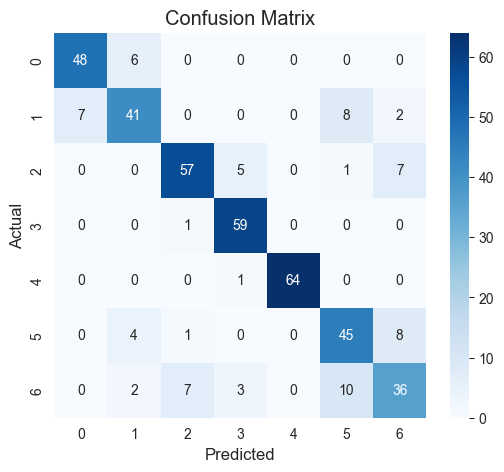

In [124]:
print("Detailed TEST Accuracy Report for Logistic Regression:\n")

print(classification_report(y_test, y_test_pred_lr))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
# plt.savefig('../results/accuracy_figures/confusion_matrices/Logistic Regression Confusion Matrix.png', dpi=300)
plt.show()

### Naive Bayes

In [101]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train, y_train)
joblib.dump(nb_model, "../models/naive_bayes_model.pkl")

['../models/naive_bayes_model.pkl']

In [102]:
y_train_pred_nb = nb_model.predict(x_train)
y_test_pred_nb = nb_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_nb))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_nb))

Training Accuracy: 0.580568720379147
Testing Accuracy: 0.6052009456264775


Detailed TEST Accuracy Report for Naive Bayes:

              precision    recall  f1-score   support

           0       0.70      0.81      0.75        54
           1       0.68      0.43      0.53        58
           2       0.37      0.56      0.45        70
           3       0.53      0.93      0.68        60
           4       0.91      0.98      0.95        65
           5       0.64      0.31      0.42        58
           6       0.67      0.17      0.27        58

    accuracy                           0.61       423
   macro avg       0.64      0.60      0.58       423
weighted avg       0.64      0.61      0.58       423



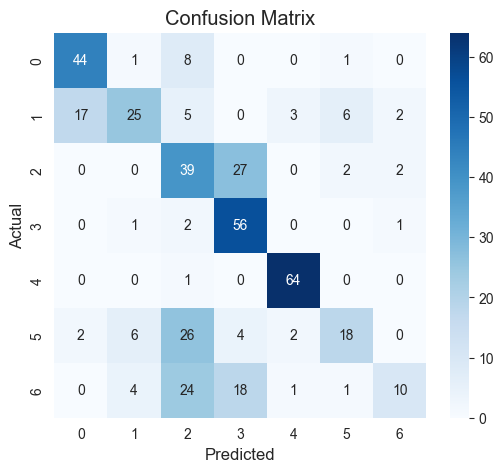

In [123]:
print("Detailed TEST Accuracy Report for Naive Bayes:\n")

print(classification_report(y_test, y_test_pred_nb))

cm_nb = confusion_matrix(y_test, y_test_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
# plt.savefig('../results/accuracy_figures/confusion_matrices/Naive Bayes Confusion Matrix.png', dpi=300)
plt.show()

### Decision Tree

In [104]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
joblib.dump(dt_model, "../models/decision_tree_model.pkl")

['../models/decision_tree_model.pkl']

In [105]:
y_train_pred_dt = dt_model.predict(x_train)
y_test_pred_dt = dt_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_dt))

Training Accuracy: 1.0
Testing Accuracy: 0.9196217494089834


Detailed TEST Accuracy Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.98      0.87      0.92        54
           1       0.79      0.83      0.81        58
           2       0.92      0.97      0.94        70
           3       0.97      0.97      0.97        60
           4       1.00      0.98      0.99        65
           5       0.84      0.88      0.86        58
           6       0.96      0.91      0.94        58

    accuracy                           0.92       423
   macro avg       0.92      0.92      0.92       423
weighted avg       0.92      0.92      0.92       423



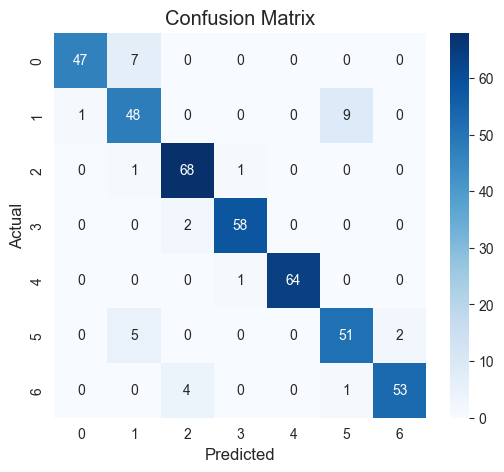

In [122]:
print("Detailed TEST Accuracy Report for Decision Tree:\n")

print(classification_report(y_test, y_test_pred_dt))

cm_dt = confusion_matrix(y_test, y_test_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
# plt.savefig('../results/accuracy_figures/confusion_matrices/Decision Tree Confusion Matrix.png', dpi=300)
plt.show()

### Random Forest

In [107]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
joblib.dump(rf_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [108]:
y_train_pred_rf = rf_model.predict(x_train)
y_test_pred_rf = rf_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))

Training Accuracy: 1.0
Testing Accuracy: 0.9479905437352246


Detailed TEST Accuracy Report for Random Forest:

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.80      0.95      0.87        58
           2       0.96      0.97      0.96        70
           3       1.00      0.98      0.99        60
           4       1.00      0.98      0.99        65
           5       0.93      0.88      0.90        58
           6       0.98      0.93      0.96        58

    accuracy                           0.95       423
   macro avg       0.95      0.95      0.95       423
weighted avg       0.95      0.95      0.95       423



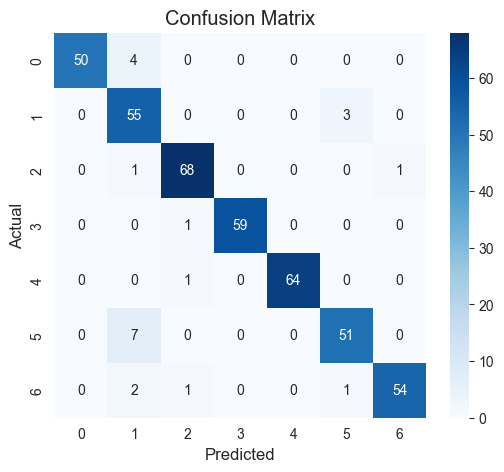

In [120]:
print("Detailed TEST Accuracy Report for Random Forest:\n")

print(classification_report(y_test, y_test_pred_rf))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
# plt.savefig('../results/accuracy_figures/confusion_matrices/Random Forest Confusion Matrix.png', dpi=300)
plt.show()

### KNN

In [110]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
joblib.dump(knn, "../models/knn_model.pkl")

['../models/knn_model.pkl']

In [111]:
y_train_pred_knn = knn.predict(x_train)
y_test_pred_knn = knn.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_knn))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_knn))

Training Accuracy: 0.9117298578199052
Testing Accuracy: 0.8723404255319149


Detailed TEST Accuracy Report for KNN:

              precision    recall  f1-score   support

           0       0.85      0.93      0.88        54
           1       0.85      0.60      0.71        58
           2       0.94      0.89      0.91        70
           3       0.92      0.97      0.94        60
           4       0.98      0.97      0.98        65
           5       0.78      0.88      0.83        58
           6       0.77      0.86      0.81        58

    accuracy                           0.87       423
   macro avg       0.87      0.87      0.87       423
weighted avg       0.88      0.87      0.87       423



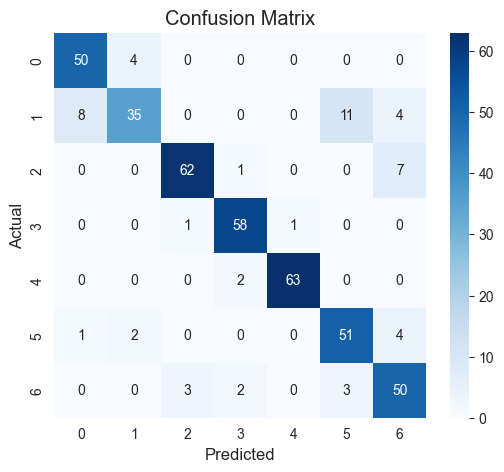

In [121]:
print("Detailed TEST Accuracy Report for KNN:\n")

print(classification_report(y_test, y_test_pred_knn))

cm_knn = confusion_matrix(y_test, y_test_pred_knn)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
# plt.savefig('../results/accuracy_figures/confusion_matrices/KNN Confusion Matrix.png', dpi=300)
plt.show()

# **Evaluation**

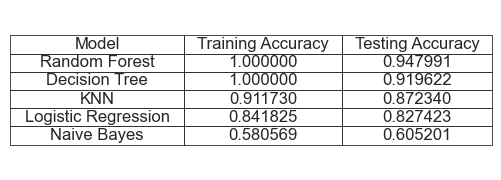

In [113]:
models = ['Random Forest', 'Decision Tree', 'KNN', 'Logistic Regression', 'Naive Bayes']

train_accuracies = [
    accuracy_score(y_train, y_train_pred_rf),
    accuracy_score(y_train, y_train_pred_dt),
    accuracy_score(y_train, y_train_pred_knn),
    accuracy_score(y_train, y_train_pred_lr),
    accuracy_score(y_train, y_train_pred_nb)
]

test_accuracies = [
    accuracy_score(y_test, y_test_pred_rf),
    accuracy_score(y_test, y_test_pred_dt),
    accuracy_score(y_test, y_test_pred_knn),
    accuracy_score(y_test, y_test_pred_lr),
    accuracy_score(y_test, y_test_pred_nb)
]

summary_train_test = pd.DataFrame({
    'Model': models,
    'Training Accuracy': train_accuracies,
    'Testing Accuracy': test_accuracies
})

formatted_data = summary_train_test.copy()
for col in ['Training Accuracy', 'Testing Accuracy']:
    formatted_data[col] = formatted_data[col].apply(lambda x: f"{x:.6f}")

fig, ax = plt.subplots(figsize=(5, 0 + len(formatted_data) * 0.38))
ax.axis('off')

table = ax.table(
    cellText=formatted_data.values,
    colLabels=formatted_data.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width(col=list(range(len(formatted_data.columns))))

plt.tight_layout()
# plt.savefig('../results/accuracy_figures/Model TRAIN-TEST Accuracies.png', dpi=300)
plt.show()

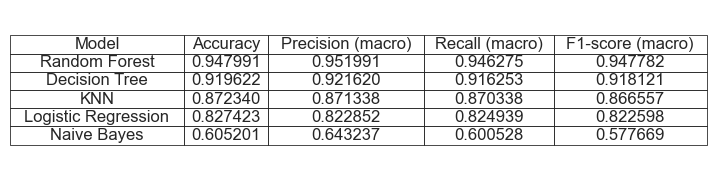

In [114]:
reports = {
    'KNN': classification_report(y_test, y_test_pred_knn, output_dict=True),
    'Random Forest': classification_report(y_test, y_test_pred_rf, output_dict=True),
    'Naive Bayes': classification_report(y_test, y_test_pred_nb, output_dict=True),
    'Decision Tree': classification_report(y_test, y_test_pred_dt, output_dict=True),
    'Logistic Regression': classification_report(y_test, y_test_pred_lr, output_dict=True)
}
summary_data = []
for model_name, report in reports.items():
    summary_data.append({
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1-score (macro)': report['macro avg']['f1-score']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(by='F1-score (macro)', ascending=False).reset_index(drop=True)

formatted_data = summary_df.copy()
for col in ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)']:
    formatted_data[col] = formatted_data[col].apply(lambda x: f"{x:.6f}")

fig, ax = plt.subplots(figsize=(7.25, 0 + len(formatted_data)*0.38))
ax.axis('off')

table = ax.table(
    cellText=formatted_data.values,
    colLabels=formatted_data.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width(col=list(range(len(formatted_data.columns))))

plt.tight_layout()
# plt.savefig('../results/accuracy_figures/Model Comparisons A.png', dpi=300)
plt.show()

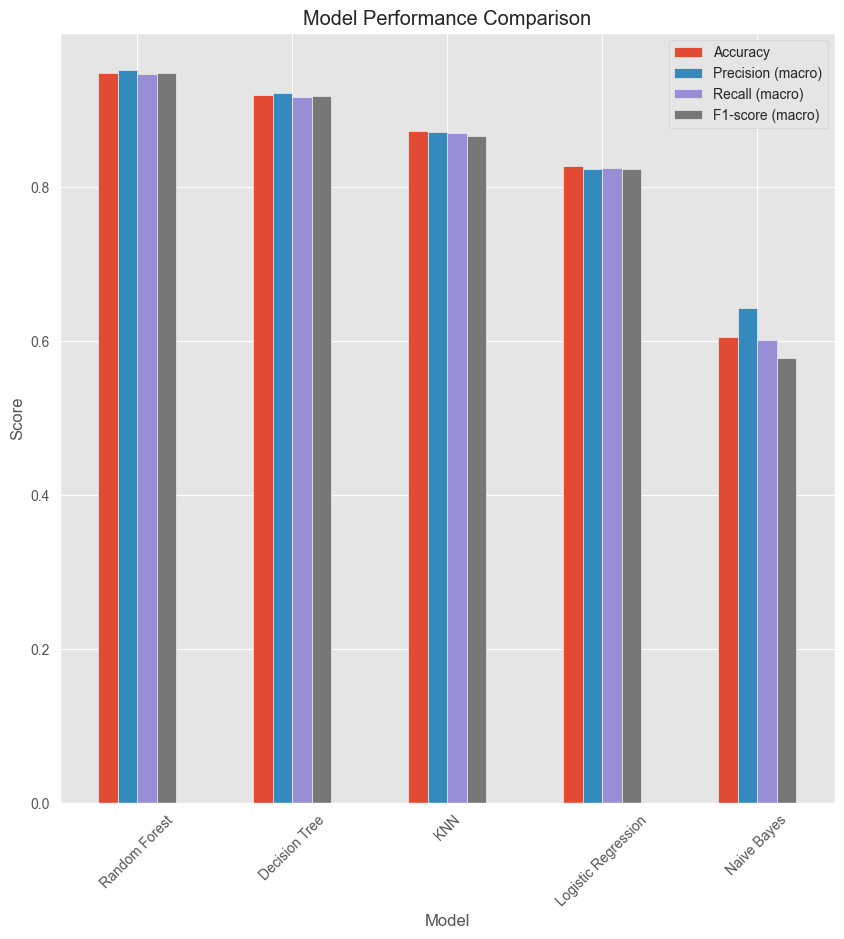

In [115]:
plt.style.use('ggplot')
summary_df.plot(
    x='Model',
    y=['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)'],
    kind='bar',
    figsize=(10,10)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='upper right')
# plt.savefig('../results/accuracy_figures/Model Comparisons B.png', dpi=300)
plt.show()

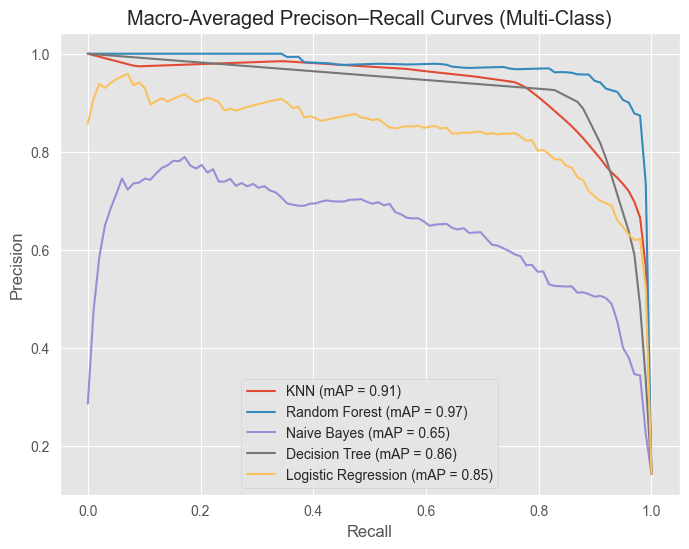

In [116]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Get class labels
classes = np.unique(y_test)
n_classes = len(classes)

# Convert true labels to one-hot format
y_test_bin = label_binarize(y_test, classes=classes)

y_test_proba_knn = knn.predict_proba(x_test)
y_test_proba_rf = rf_model.predict_proba(x_test)
y_test_proba_nb = nb_model.predict_proba(x_test)
y_test_proba_dt = dt_model.predict_proba(x_test)
y_test_proba_lr = lr_model.predict_proba(x_test)

models = {
    'KNN': y_test_proba_knn,
    'Random Forest': y_test_proba_rf,
    'Naive Bayes': y_test_proba_nb,
    'Decision Tree': y_test_proba_dt,
    'Logistic Regression': y_test_proba_lr
}

plt.figure(figsize=(8,6))

for name, proba in models.items():
    precision = dict()
    recall = dict()
    avg_precision = dict()

    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
        avg_precision[i] = average_precision_score(y_test_bin[:, i], proba[:, i])

    # Compute macro-average (mean across classes)
    all_precision = np.linspace(0, 1, 100)
    mean_recall = np.zeros_like(all_precision)

    for i in range(n_classes):
        mean_recall += np.interp(all_precision, recall[i][::-1], precision[i][::-1])
    mean_recall /= n_classes

    macro_avg_precision = np.mean(list(avg_precision.values()))
    plt.plot(all_precision, mean_recall, label=f'{name} (mAP = {macro_avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-Averaged Precison–Recall Curves (Multi-Class)')
plt.legend()
plt.grid(True)
# plt.savefig('../results/accuracy_figures/Precision-Recall Curves.png', dpi=300)
plt.show()

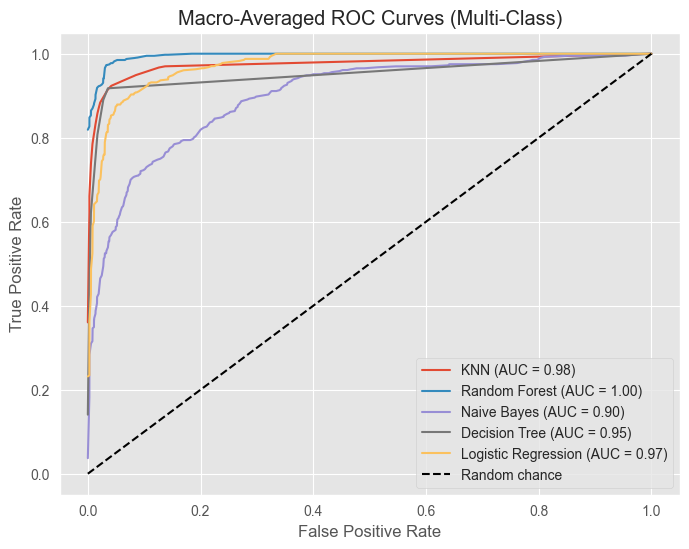

In [117]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

plt.figure(figsize=(8,6))

for name, proba in models.items():
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute ROC curve and AUC for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute macro-average ROC curve
    # Aggregate all FPR points
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    # Interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    macro_roc_auc = roc_auc_score(y_test_bin, proba, average='macro')

    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {macro_roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Averaged ROC Curves (Multi-Class)')
plt.legend(loc='lower right')
plt.grid(True)
# plt.savefig('../results/accuracy_figures/ROC Curves.png', dpi=300)
plt.show()

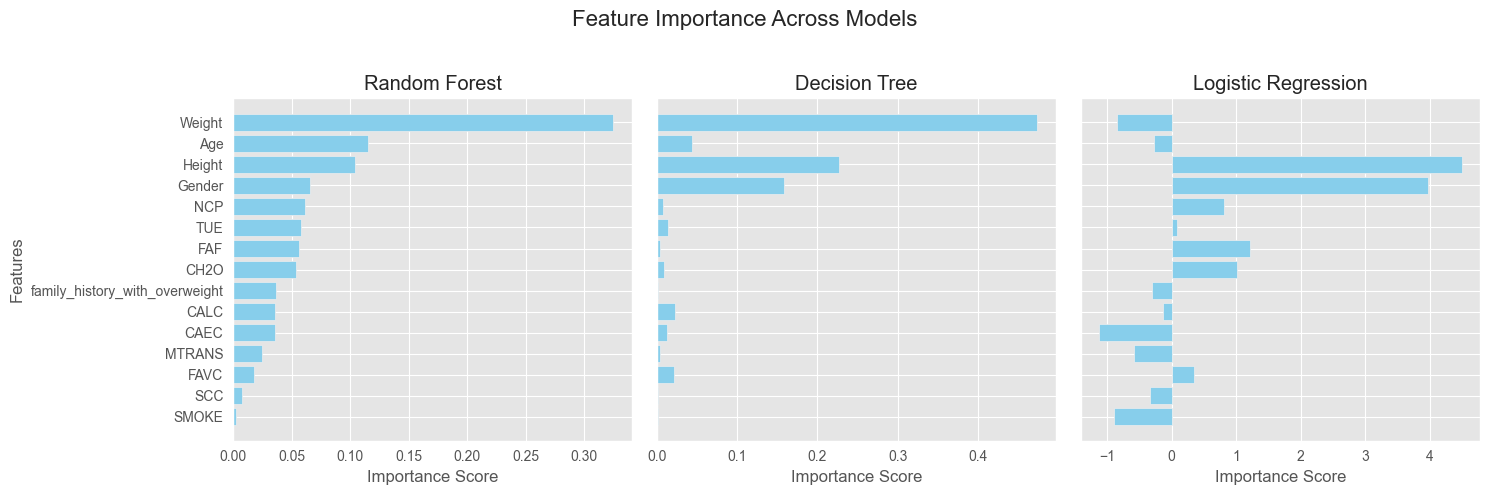

In [118]:
models = {
    'Random Forest': rf_model,
    'Decision Tree': dt_model,
    'Logistic Regression': lr_model,
    # KNN and Naive Bayes do not have built-in importances
}

n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models,5), sharey=True)

for i, (name, model) in enumerate(models.items()):
    # Feature importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = model.coef_[0]

    feat_imp = pd.Series(importances, index=x_train.columns).sort_values(ascending=True)

    # Plot horizontal bar
    axes[i].barh(feat_imp.index, feat_imp.values, color='skyblue')
    axes[i].set_title(name)
    axes[i].set_xlabel("Importance Score")

axes[0].set_ylabel("Features")
plt.suptitle("Feature Importance Across Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('../results/accuracy_figures/Feature Importance Across Models.png', dpi=300)
plt.show()